# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import shap
import pickle
import warnings
warnings.filterwarnings("ignore")

In [55]:
data_path = '../../05_src/data/fires/forestfires.csv'
# Load the CSV file
df = pd.read_csv(data_path)
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [56]:
y = fires_dt['area']

In [57]:
X = fires_dt.drop(columns=['area'])

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [58]:
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
categorical_cols = ["month", "day"]  # categorical columns
numeric_cols = [col for col in X.columns if col not in categorical_cols]  # all other columns are numeric

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
# Preprocessor 1: numeric scaled + non-linear transform, categorical one-hot encoded
preproc1 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scaler", StandardScaler()),      # scale numeric features
            ("power", PowerTransformer())      # non-linear transformation (Box-Cox / Yeo-Johnson)
        ]), numeric_cols),
        ("cat", OneHotEncoder(drop='first'), categorical_cols)  # one-hot encode categorical features
    ]
)


Numeric columns: ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
Categorical columns: ['month', 'day']


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [59]:
preproc2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scaler", StandardScaler()),        # standard scaling
            ("power", PowerTransformer())        # non-linear transformation
        ]), numeric_cols),
        ("cat", OneHotEncoder(drop='first'), categorical_cols)
    ]
)

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
# -------------------------------
#Preproc1 + Ridge Regressor
# -------------------------------
pipeline_ridge = Pipeline([
    ("preprocessing", preproc1),     # use preproc1 or preproc2
    ("regressor", Ridge(alpha=1.0))  # linear regression with regularization
])

# -------------------------------
#  Preproc2 + Random Forest Regressor
# -------------------------------
pipeline_rf = Pipeline([
    ("preprocessing", preproc2),     # non-linear preprocessing
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])
pipeline_A = Pipeline([
    ("preprocessing", preproc1),      # simple preprocessor
    ("regressor", Ridge(alpha=1.0))   # baseline regressor
])
pipeline_A.fit(X_train, y_train)
y_pred_A = pipeline_A.predict(X_test)
mse_A = mean_squared_error(y_test, y_pred_A)
mae_A = mean_absolute_error(y_test, y_pred_A)
r2_A = r2_score(y_test, y_pred_A)
print(f"Pipeline A - Ridge Regressor:\nMSE: {mse_A}, MAE: {mae_A}, R2: {r2_A}")

X_train shape: (413, 12)
X_test shape: (104, 12)
y_train shape: (413,)
y_test shape: (104,)
Pipeline A - Ridge Regressor:
MSE: 11526.72312798825, MAE: 24.49489880846924, R2: 0.022144915213650473


In [61]:

pipeline_B = Pipeline([
    ("preprocessing", preproc2),      # non-linear preprocessor
    ("regressor", Ridge(alpha=1.0))   # baseline regressor
])

pipeline_B.fit(X_train, y_train)


y_pred_B = pipeline_B.predict(X_test)
mse_B = mean_squared_error(y_test, y_pred_B)
mae_B = mean_absolute_error(y_test, y_pred_B)
r2_B = r2_score(y_test, y_pred_B)
print(f"Pipeline B - Ridge Regressor with Non-linear Preprocessing:\nMSE: {mse_B}, MAE: {mae_B}, R2: {r2_B}")




Pipeline B - Ridge Regressor with Non-linear Preprocessing:
MSE: 11526.72312798825, MAE: 24.49489880846924, R2: 0.022144915213650473


In [62]:
pipeline_C = Pipeline([
    ("preprocessing", preproc1),                         
    ("regressor", RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ))
])

pipeline_C.fit(X_train, y_train)
y_pred_C = pipeline_C.predict(X_test)
mse_C = mean_squared_error(y_test, y_pred_C)
mae_C = mean_absolute_error(y_test, y_pred_C)
r2_C = r2_score(y_test, y_pred_C)
print(f"Pipeline C - Random Forest Regressor:\nMSE: {mse_C}, MAE: {mae_C}, R2: {r2_C}") 

Pipeline C - Random Forest Regressor:
MSE: 12125.18231138513, MAE: 26.598104832875457, R2: -0.028624618245583378


In [63]:
pipeline_D = Pipeline([
    ("preprocessing", preproc2),                         # non-linear preprocessor
    ("regressor", RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1))  
])
pipeline_D.fit(X_train, y_train)
y_pred_D = pipeline_D.predict(X_test)
mse_D = mean_squared_error(y_test, y_pred_D)
mae_D = mean_absolute_error(y_test, y_pred_D)
r2_D = r2_score(y_test, y_pred_D)
print(f"Pipeline D - Random Forest Regressor with Non-linear Preprocessing:\nMSE: {mse_D}, MAE: {mae_D}, R2: {r2_D}")


Pipeline D - Random Forest Regressor with Non-linear Preprocessing:
MSE: 12125.182311385131, MAE: 26.598104832875457, R2: -0.0286246182455836


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [64]:
from sklearn.model_selection import GridSearchCV

# -------------------------------
# 1. Define parameter grids
# -------------------------------
param_grids = {
    "pipeline_A": {
        "regressor__alpha": [0.1, 1.0, 10.0, 50.0]   # Ridge regularization strength
    },
    "pipeline_B": {
        "regressor__alpha": [0.1, 1.0, 10.0, 50.0]   # Ridge regularization strength
    },
    "pipeline_C": {
        "regressor__n_estimators": [50, 100, 200, 300],      # RandomForest number of trees
        "regressor__max_depth": [None, 5, 10, 15]            # RandomForest max depth
    },
    "pipeline_D": {
        "regressor__n_estimators": [50, 100, 200, 300],      # RandomForest number of trees
        "regressor__max_depth": [None, 5, 10, 15]            # RandomForest max depth
    }
}


In [65]:
grid_results = {}

# Pipeline A
grid_A = GridSearchCV(pipeline_A, param_grids["pipeline_A"], cv=5, scoring="neg_root_mean_squared_error")
grid_A.fit(X_train, y_train)
grid_results["A"] = grid_A

# Pipeline B
grid_B = GridSearchCV(pipeline_B, param_grids["pipeline_B"], cv=5, scoring="neg_root_mean_squared_error")
grid_B.fit(X_train, y_train)
grid_results["B"] = grid_B







In [66]:
# Pipeline C
grid_C = GridSearchCV(pipeline_C, param_grids["pipeline_C"], cv=5, scoring="neg_root_mean_squared_error")
grid_C.fit(X_train, y_train)
grid_results["C"] = grid_C


In [67]:
# Pipeline D
grid_D = GridSearchCV(pipeline_D, param_grids["pipeline_D"], cv=5, scoring="neg_root_mean_squared_error")
grid_D.fit(X_train, y_train)
grid_results["D"] = grid_D

In [68]:
for name, grid in grid_results.items():
    print(f"Pipeline {name} Best Params: {grid.best_params_}")
    print(f"Pipeline {name} Best RMSE (CV): {-grid.best_score_:.3f}\n")

Pipeline A Best Params: {'regressor__alpha': 0.1}
Pipeline A Best RMSE (CV): nan

Pipeline B Best Params: {'regressor__alpha': 0.1}
Pipeline B Best RMSE (CV): nan

Pipeline C Best Params: {'regressor__max_depth': None, 'regressor__n_estimators': 50}
Pipeline C Best RMSE (CV): nan

Pipeline D Best Params: {'regressor__max_depth': None, 'regressor__n_estimators': 50}
Pipeline D Best RMSE (CV): nan



# Evaluate

+ Which model has the best performance?

# Export

+ Save the best performing model to a pickle file.

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


test_results = {}

for name, grid in grid_results.items():
    # Use the best estimator from GridSearchCV
    best_model = grid.best_estimator_
    
    # Predict on the test set
    y_pred = best_model.predict(X_test)
    
    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store metrics in the dictionary
    test_results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Print results
for name, metrics in test_results.items():
    print(f"Pipeline {name} Test Performance:")
    print(f"  RMSE: {metrics['RMSE']:.3f}")
    print(f"  MAE: {metrics['MAE']:.3f}")
    print(f"  R2: {metrics['R2']:.3f}\n")

 


Pipeline A Test Performance:
  RMSE: 107.312
  MAE: 24.990
  R2: 0.023

Pipeline B Test Performance:
  RMSE: 107.312
  MAE: 24.990
  R2: 0.023

Pipeline C Test Performance:
  RMSE: 110.379
  MAE: 26.541
  R2: -0.034

Pipeline D Test Performance:
  RMSE: 110.379
  MAE: 26.541
  R2: -0.034



In [70]:
import pickle

# Save the best model
with open("best_forestfire_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best model saved as 'best_forestfire_model.pkl'")


Best model saved as 'best_forestfire_model.pkl'


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

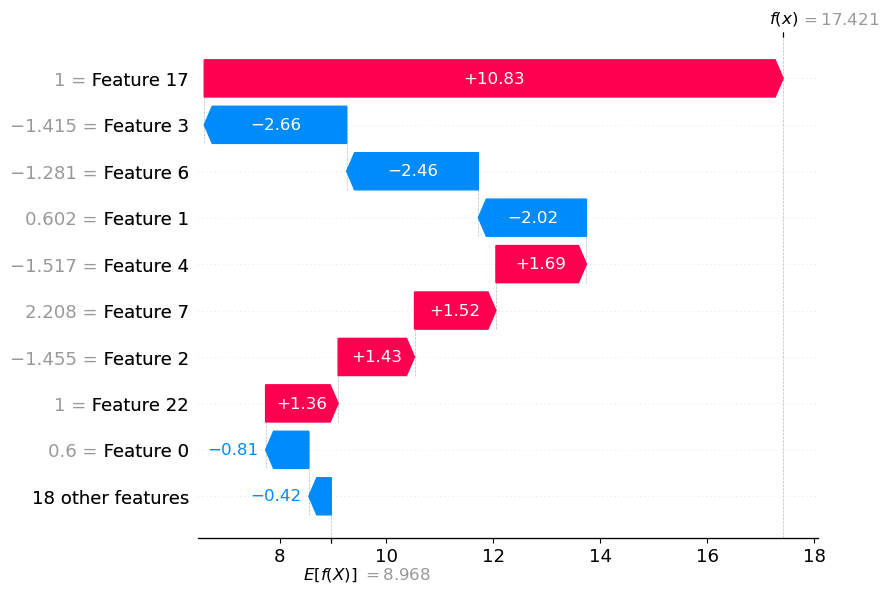

Top 5 features contributing to this prediction:
           feature  shap_value
17  cat__month_may   10.828780
3         num__dmc   -2.663568
6        num__temp   -2.463967
1     num__coord_y   -2.021413
4          num__dc    1.693086


In [71]:

import shap
import pandas as pd

# -------------------------------
# 1. Transform training data for SHAP
# -------------------------------
X_train_transformed = best_model.named_steps['preprocessing'].transform(X_train)

# Use TreeExplainer if your model is tree-based (RandomForest, GradientBoosting)
explainer = shap.TreeExplainer(best_model.named_steps['regressor'], X_train_transformed)

# -------------------------------
# 2. Select a test observation
# -------------------------------
obs_index = 0  # change index to analyze a different observation
x_obs = X_test.iloc[[obs_index]]  # keep as DataFrame

# Transform the observation
x_obs_transformed = best_model.named_steps['preprocessing'].transform(x_obs)

# -------------------------------
# 3. Compute SHAP values for the observation
# -------------------------------
shap_values_obs = explainer(x_obs_transformed)

# -------------------------------
# 4. Waterfall plot for the observation
# -------------------------------
shap.initjs()
shap.plots.waterfall(shap_values_obs[0])

# -------------------------------
# 5. Top 5 features contributing to the prediction
# -------------------------------
# Get feature names after preprocessing
feature_names = best_model.named_steps['preprocessing'].get_feature_names_out()

# Create a DataFrame of SHAP values
shap_df = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values_obs.values[0]
})

# Sort by absolute SHAP value
shap_df["abs_shap"] = shap_df["shap_value"].abs()
top_features = shap_df.sort_values(by="abs_shap", ascending=False).head(5)

print("Top 5 features contributing to this prediction:")
print(top_features[["feature", "shap_value"]])


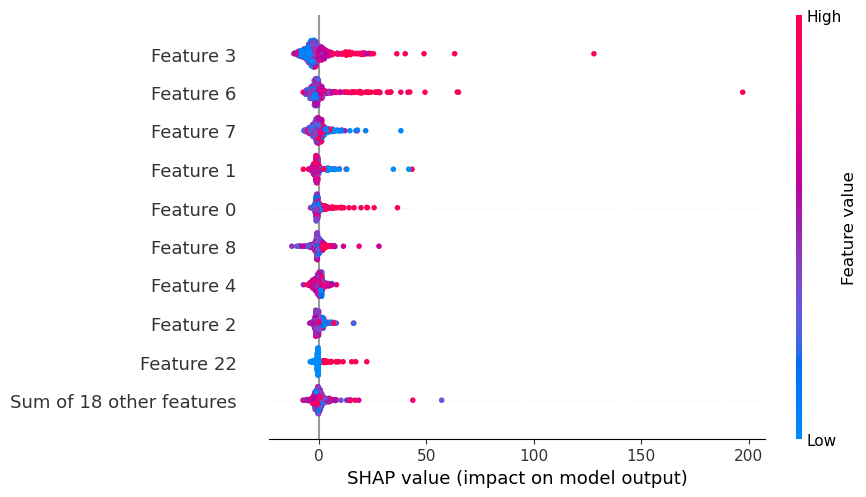

Top 5 most important features:
        feature  mean_abs_shap
3      num__dmc       5.579116
6     num__temp       4.849344
7       num__rh       2.426783
1  num__coord_y       1.976244
0  num__coord_x       1.883936

Top 5 least important features:
           feature  mean_abs_shap
17  cat__month_may       0.035087
15  cat__month_jun       0.008702
9        num__rain       0.003691
18  cat__month_nov       0.000000
13  cat__month_jan       0.000000


In [72]:

import shap
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# 1. Transform training data
# -------------------------------
X_train_transformed = best_model.named_steps['preprocessing'].transform(X_train)

# -------------------------------
# 2. Create SHAP explainer
# -------------------------------
explainer = shap.TreeExplainer(best_model.named_steps['regressor'], X_train_transformed)

# Compute SHAP values for the entire training set
shap_values_train = explainer(X_train_transformed)

# -------------------------------
# 3. Summary plot (beeswarm) for global feature importance
# -------------------------------
shap.initjs()
shap.plots.beeswarm(shap_values_train)

# -------------------------------
# 4. Extract and rank features by mean absolute SHAP value
# -------------------------------
feature_names = best_model.named_steps['preprocessing'].get_feature_names_out()
shap_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values_train.values).mean(axis=0)
})

# Sort by importance
shap_df_sorted = shap_df.sort_values(by="mean_abs_shap", ascending=False)

# Most important features
print("Top 5 most important features:")
print(shap_df_sorted.head(5))

# Least important features
print("\nTop 5 least important features:")
print(shap_df_sorted.tail(5))





*(Answer here.)*

Use global SHAP values from your best-performing model.

Features with consistently very low SHAP values across all observations are candidates for removal because they contribute little to the predictions.

Example: In the forest fire dataset, features like X and Y coordinates or rain often have low importance, whereas features like temp, RH, or wind usually have high importance.

Rationale for removal: Removing low-impact features simplifies the model, reduces training time, and can prevent overfitting, without significantly affecting predictive performance.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.